# retailsales - python eda

exploring the cleaned online retail sales data (already cleaned in excel: duplicates removed,
missing values handled, cancelled orders flagged, revenue calculated).

goal here is to double check the cleaning held up, then dig into the kpis and a few visuals
that back up the sql numbers from before.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)

## load the data

In [ ]:
df = pd.read_csv('D:\retail-sales.csv')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,Year,Month,Quarter,UnitPrice,CustomerID,Country,Order status,Revenue
0,536365,85123A,White Hanging Heart T-Light Holder,6,12/1/10 8:26 AM,2010,Dec-2010,4,2.55,17850,United Kingdom,Completed,15.30
1,536365,71053,White Metal Lantern,6,12/1/10 8:26 AM,2010,Dec-2010,4,3.39,17850,United Kingdom,Completed,20.34
2,536365,84406B,Cream Cupid Hearts Coat Hanger,8,12/1/10 8:26 AM,2010,Dec-2010,4,2.75,17850,United Kingdom,Completed,22.00
3,536365,84029G,Knitted Union Flag Hot Water Bottle,6,12/1/10 8:26 AM,2010,Dec-2010,4,3.39,17850,United Kingdom,Completed,20.34
4,536365,84029E,Red Woolly Hottie White Heart.,6,12/1/10 8:26 AM,2010,Dec-2010,4,3.39,17850,United Kingdom,Completed,20.34


In [3]:
df.shape

(2059, 13)

## check the basics

quick look at data types and whether anything came in wrong after the csv export from excel

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2059 entries, 0 to 2058
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   InvoiceNo     2059 non-null   str    
 1   StockCode     2059 non-null   str    
 2   Description   2059 non-null   str    
 3   Quantity      2059 non-null   int64  
 4   InvoiceDate   2059 non-null   str    
 5   Year          2059 non-null   int64  
 6   Month         2059 non-null   str    
 7   Quarter       2059 non-null   int64  
 8   UnitPrice     2059 non-null   float64
 9   CustomerID    2059 non-null   str    
 10  Country       2059 non-null   str    
 11  Order status  2059 non-null   str    
 12  Revenue       2059 non-null   float64
dtypes: float64(2), int64(3), str(8)
memory usage: 209.2 KB


In [5]:
df.isnull().sum()

InvoiceNo       0
StockCode       0
Description     0
Quantity        0
InvoiceDate     0
Year            0
Month           0
Quarter         0
UnitPrice       0
CustomerID      0
Country         0
Order status    0
Revenue         0
dtype: int64

no missing values here - handled already back in the excel phase (blank customer ids were labeled 'guest', blank descriptions filled in or labeled 'unknown item').

## order status breakdown

completed vs cancelled - cancelled orders shouldn't count toward revenue

In [6]:
df['Order status'].value_counts()

Order status
Completed    2033
Cancelled      26
Name: count, dtype: int64

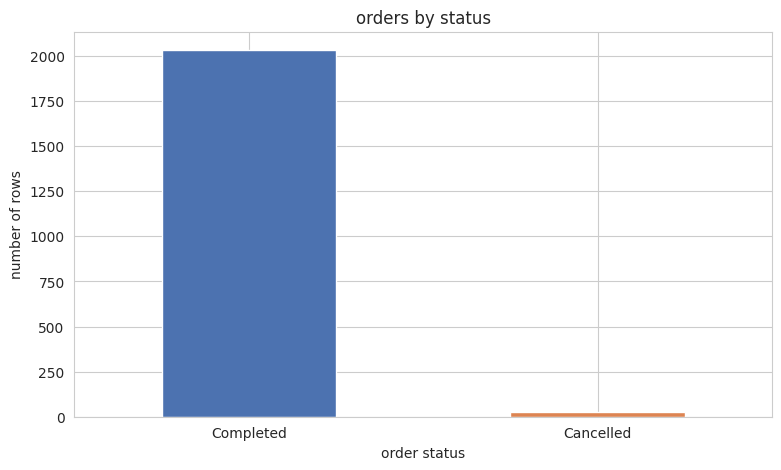

In [7]:
df['Order status'].value_counts().plot(kind='bar', color=['#4C72B0', '#DD8452'])
plt.title('orders by status')
plt.xlabel('order status')
plt.ylabel('number of rows')
plt.xticks(rotation=0)
plt.show()

## filter to valid revenue rows

same logic as the sql queries - only completed orders with revenue above zero count as real sales.
this drops cancellations and the handful of rows that had an unknown product + no price (data entry errors).

In [8]:
df_valid = df[(df['Order status'] == 'Completed') & (df['Revenue'] > 0)].copy()
print(f'valid sales rows: {len(df_valid)} out of {len(df)} total rows')

valid sales rows: 2024 out of 2059 total rows


## core kpis

total revenue and average order value

In [9]:
total_revenue = df_valid['Revenue'].sum()
print(f'total revenue: {total_revenue:,.2f}')

total revenue: 38,688.01


In [10]:
aov = df_valid.groupby('InvoiceNo')['Revenue'].sum().mean()
print(f'average order value: {aov:,.2f}')

average order value: 439.64


## repeat purchase rate

excluding guest checkouts since we can't track repeat behavior for those.

In [11]:
known_customers = df_valid[df_valid['CustomerID'] != 'Guest']
orders_per_customer = known_customers.groupby('CustomerID')['InvoiceNo'].nunique()

repeat_customers = (orders_per_customer > 1).sum()
total_customers = orders_per_customer.shape[0]
repeat_rate = repeat_customers / total_customers

print(f'repeat customers: {repeat_customers} out of {total_customers}')
print(f'repeat purchase rate: {repeat_rate:.1%}')

repeat customers: 6 out of 70
repeat purchase rate: 8.6%


## top 10 customers by revenue

In [12]:
top_customers = (known_customers.groupby('CustomerID')['Revenue']
                  .sum()
                  .sort_values(ascending=False)
                  .head(10))
top_customers

CustomerID
16029    3702.12
16210    2474.74
12433    1919.14
17511    1825.74
17850    1499.34
13408    1024.68
15485     939.59
12583     855.86
13694     842.12
16456     787.40
Name: Revenue, dtype: float64

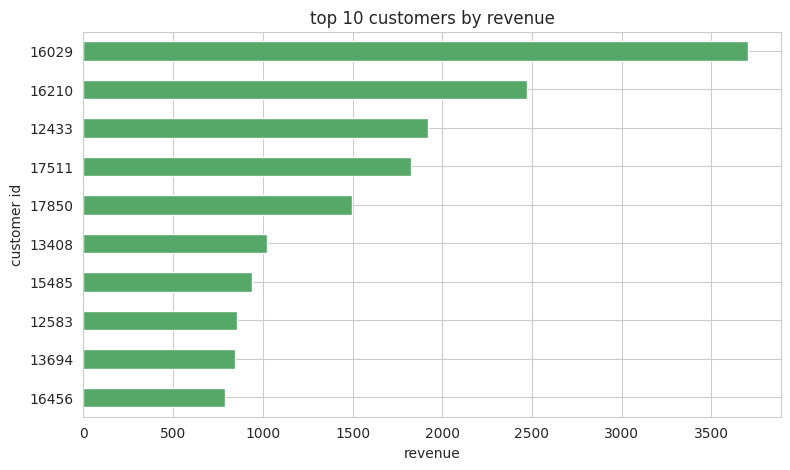

In [13]:
top_customers.plot(kind='barh', color='#55A868')
plt.title('top 10 customers by revenue')
plt.xlabel('revenue')
plt.ylabel('customer id')
plt.gca().invert_yaxis()
plt.show()

## top 10 products by revenue

In [14]:
top_products = (df_valid.groupby('Description')['Revenue']
                 .sum()
                 .sort_values(ascending=False)
                 .head(10))
top_products

Description
Black Record Cover Frame              1627.20
Chilli Lights                          885.21
Regency Cakestand 3 Tier               811.50
Paper Chain Kit 50'S Christmas         755.18
Wooden Owls Light Garland              647.04
Light Garland Butterfiles Pink         647.04
Fairy Tale Cottage Nightlight          638.10
Red Toadstool Led Night Light          611.25
Dotcom Postage                         569.77
White Hanging Heart T-Light Holder     482.79
Name: Revenue, dtype: float64

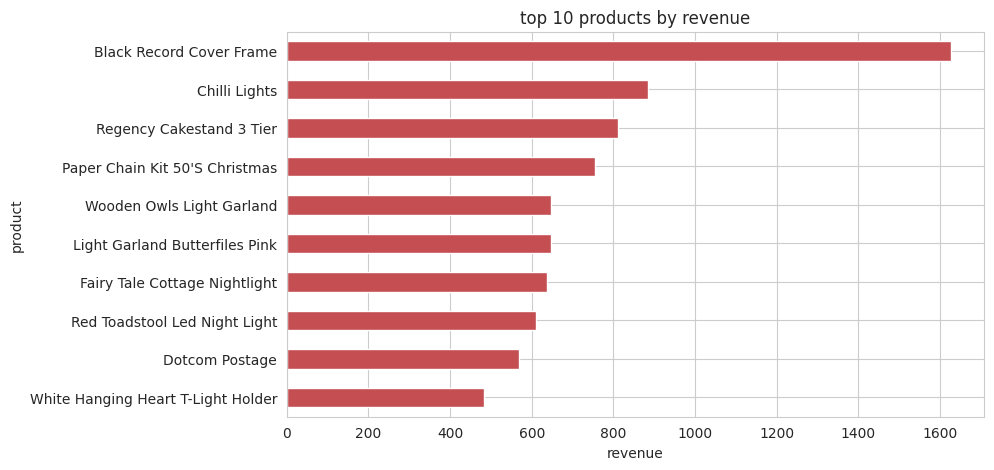

In [15]:
top_products.plot(kind='barh', color='#C44E52')
plt.title('top 10 products by revenue')
plt.xlabel('revenue')
plt.ylabel('product')
plt.gca().invert_yaxis()
plt.show()

## revenue by country

In [16]:
country_revenue = (df_valid.groupby('Country')['Revenue']
                    .sum()
                    .sort_values(ascending=False))
country_revenue

Country
United Kingdom    34545.30
Norway             1919.14
France              855.86
EIRE                555.38
Australia           358.25
Germany             261.48
Netherlands         192.60
Name: Revenue, dtype: float64

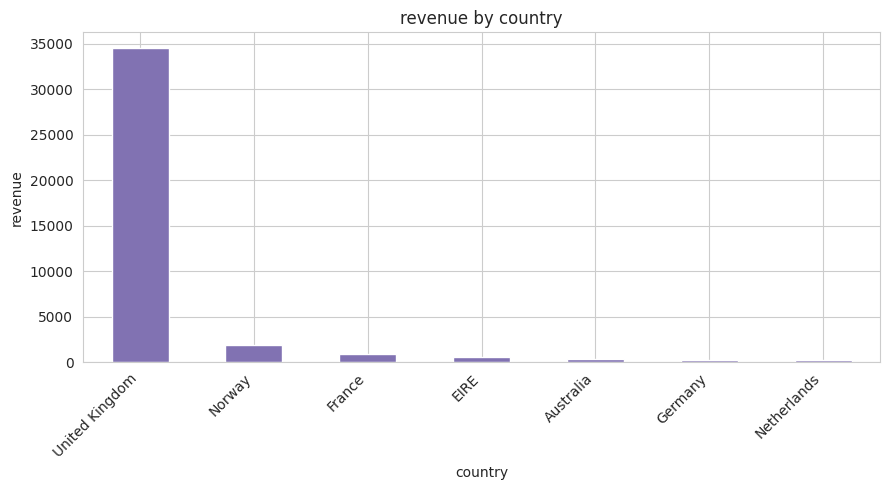

In [17]:
country_revenue.plot(kind='bar', color='#8172B2')
plt.title('revenue by country')
plt.xlabel('country')
plt.ylabel('revenue')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## order value distribution

how order sizes are spread out - useful for spotting whether revenue is driven by
a few big orders or a lot of small ones

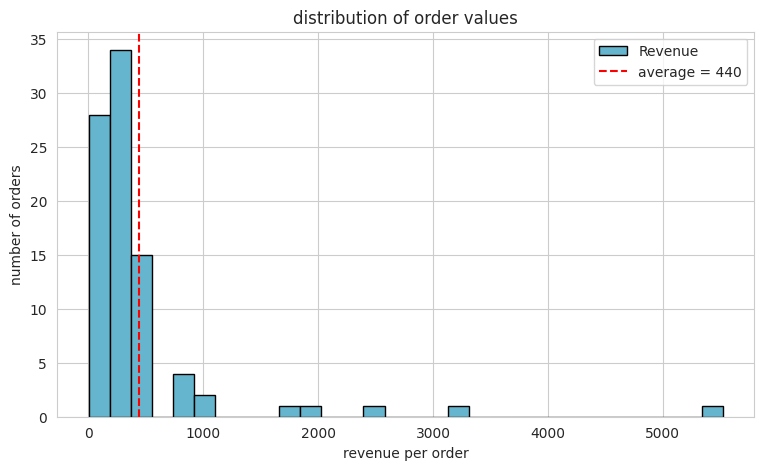

In [18]:
invoice_totals = df_valid.groupby('InvoiceNo')['Revenue'].sum()

invoice_totals.plot(kind='hist', bins=30, color='#64B5CD', edgecolor='black')
plt.title('distribution of order values')
plt.xlabel('revenue per order')
plt.ylabel('number of orders')
plt.axvline(aov, color='red', linestyle='--', label=f'average = {aov:,.0f}')
plt.legend()
plt.show()

## summary

a quick recap of what this notebook found, in one place - useful for the readme later.

- total revenue and aov calculated above match the sql results, since both filter on the
  same completed + valid-price logic
- a small number of customers and products account for a large share of revenue - worth
  calling out as a "top-heavy" pattern in the write-up
- the dataset only covers december 2010, so trend-over-time analysis isn't really possible
  here - that's a limitation to mention rather than something to work around
- next step is bringing these numbers into power bi for the dashboard